In [1]:
pwd

'C:\\code\\Project 1\\dataset'

In [2]:
import pandas as pd

In [4]:
df_booking = pd.read_csv("fact_bookings.csv")
df_booking.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640


In [7]:
df_booking.shape

(134590, 12)

In [8]:
df_booking.room_category.unique()

array(['RT1', 'RT2', 'RT3', 'RT4'], dtype=object)

In [9]:
df_booking.booking_platform.unique()

array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

In [10]:
df_booking.booking_platform.value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

<Axes: xlabel='booking_platform'>

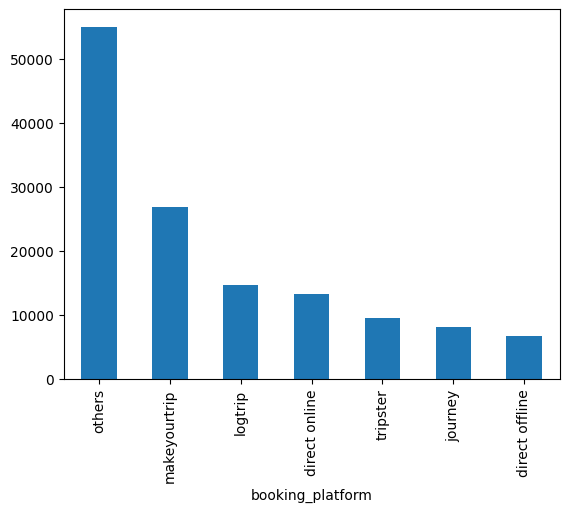

In [12]:
df_booking.booking_platform.value_counts().plot(kind="bar")

In [13]:
df_booking.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [19]:
df_date = pd.read_csv("dim_date.csv")
df_hotels = pd.read_csv("dim_hotels.csv")
df_room = pd.read_csv("dim_rooms.csv")
df_fact_booking = pd.read_csv("fact_aggregated_bookings.csv")
df_booking = pd.read_csv("fact_bookings.csv")


In [17]:
df_fact_booking.head(4)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0


In [22]:
df_booking.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [23]:
df_booking[df_booking.no_guests<=0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [25]:
df_booking.shape

(134590, 12)

In [28]:
df_booking = df_booking[df_booking.no_guests>0]

In [29]:
df_booking.shape

(134578, 12)

In [30]:
df_booking.revenue_generated.min(), df_booking.revenue_generated.max()

(np.int64(6500), np.int64(28560000))

In [32]:
df_booking.revenue_generated.mean(), df_booking.revenue_generated.std()

(np.float64(15378.036937686695), np.float64(93040.1549314641))

In [33]:
avg , std = df_booking.revenue_generated.mean(), df_booking.revenue_generated.std()

In [39]:
higher_limit = avg + 3*std
higher_limit

np.float64(294498.50173207896)

In [37]:
lower_limit = avg - 3*std

In [38]:
lower_limit

np.float64(-263742.4278567056)

In [42]:
df_booking = df_booking[df_booking.revenue_generated<higher_limit]

In [43]:
df_booking.shape

(134573, 12)

In [45]:
df_booking.revenue_realized.describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [47]:
higher_limit_rr = df_booking.revenue_realized.mean() + 3*df_booking.revenue_realized.std()

In [48]:
higher_limit_rr

np.float64(33479.358661845814)

In [50]:
df_booking[df_booking.revenue_realized>higher_limit_rr]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


In [52]:
df_booking[df_booking.room_category=="RT4"].revenue_realized.describe()

count    16071.000000
mean     23439.308444
std       9048.599076
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

In [53]:
23439.308444 + 3*9048.599076

50585.105672000005

In [55]:
df_booking.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100
6,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
7,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134584,Jul312217564RT45,17564,30-07-22,31-07-22,1/8/2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-22,31-07-22,3/8/2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134587,Jul312217564RT48,17564,30-07-22,31-07-22,2/8/2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-22,31-07-22,1/8/2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


-80.0

In [60]:
df_fact_booking.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0


In [66]:
df_fact_booking["Occ_pct"] = df_fact_booking["successful_bookings"]/df_fact_booking["capacity"]

In [68]:
df_fact_booking.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct
0,16559,1-May-22,RT1,25,30.0,0.833333
1,19562,1-May-22,RT1,28,30.0,0.933333
2,19563,1-May-22,RT1,23,30.0,0.766667
3,17558,1-May-22,RT1,30,19.0,1.578947
4,16558,1-May-22,RT1,18,19.0,0.947368


In [70]:
df_fact_booking["Occ_pct"] = df_fact_booking["Occ_pct"].apply(lambda x: round(x*100,2))

In [72]:
 df_fact_booking.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
3,17558,1-May-22,RT1,30,19.0,157.89
4,16558,1-May-22,RT1,18,19.0,94.74


In [80]:
df_fact_booking["occ_pct_avg"] = df_fact_booking.groupby("room_category")["Occ_pct"].mean()

In [81]:
df_fact_booking.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct,occ_pct_avg
0,16559,1-May-22,RT1,25,30.0,83.33,NaN
1,19562,1-May-22,RT1,28,30.0,93.33,NaN
2,19563,1-May-22,RT1,23,30.0,76.67,NaN
3,17558,1-May-22,RT1,30,19.0,157.89,NaN
4,16558,1-May-22,RT1,18,19.0,94.74,NaN


In [83]:
df_room

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [84]:
df_rc = pd.merge(df_fact_booking , df_room , left_on="room_category",right_on="room_id")

In [87]:
df_rc.tail(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct,occ_pct_avg,room_id,room_class
9195,16563,31-Jul-22,RT4,13,18.0,72.22,NaN,RT4,Presidential
9196,16559,31-Jul-22,RT4,13,18.0,72.22,NaN,RT4,Presidential
9197,17558,31-Jul-22,RT4,3,6.0,50.00,NaN,RT4,Presidential
9198,19563,31-Jul-22,RT4,3,6.0,50.00,NaN,RT4,Presidential
9199,17561,31-Jul-22,RT4,3,4.0,75.00,NaN,RT4,Presidential


In [89]:
df_hotels.head(5)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [98]:
df_oh = pd.merge(df_rc,df_hotels,on="property_id")

In [92]:
df_oh.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct,occ_pct_avg,room_id,room_class,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,83.33,NaN,RT1,Standard,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,28,30.0,93.33,NaN,RT1,Standard,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,RT1,23,30.0,76.67,NaN,RT1,Standard,Atliq Palace,Business,Bangalore
3,17558,1-May-22,RT1,30,19.0,157.89,NaN,RT1,Standard,Atliq Grands,Luxury,Mumbai
4,16558,1-May-22,RT1,18,19.0,94.74,NaN,RT1,Standard,Atliq Grands,Luxury,Delhi


In [93]:
df_oh.groupby("city")['Occ_pct'].mean()

In [100]:
df_oh.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct,occ_pct_avg,room_id,room_class,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,83.33,NaN,RT1,Standard,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,28,30.0,93.33,NaN,RT1,Standard,Atliq Bay,Luxury,Bangalore
2,19563,1-May-22,RT1,23,30.0,76.67,NaN,RT1,Standard,Atliq Palace,Business,Bangalore
3,17558,1-May-22,RT1,30,19.0,157.89,NaN,RT1,Standard,Atliq Grands,Luxury,Mumbai
4,16558,1-May-22,RT1,18,19.0,94.74,NaN,RT1,Standard,Atliq Grands,Luxury,Delhi


In [96]:
df_date.head(5)

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [102]:
df_city_op = pd.merge(df_oh ,df_date , left_on="check_in_date" ,right_on="date" )
df_city_op.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct,occ_pct_avg,room_id,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,19563,10-May-22,RT3,15,29.0,51.72,NaN,RT3,Premium,Atliq Palace,Business,Bangalore,10-May-22,May 22,W 20,weekeday
1,18560,10-May-22,RT1,19,30.0,63.33,NaN,RT1,Standard,Atliq City,Business,Hyderabad,10-May-22,May 22,W 20,weekeday
2,19562,10-May-22,RT1,18,30.0,60.00,NaN,RT1,Standard,Atliq Bay,Luxury,Bangalore,10-May-22,May 22,W 20,weekeday
3,19563,10-May-22,RT1,16,30.0,53.33,NaN,RT1,Standard,Atliq Palace,Business,Bangalore,10-May-22,May 22,W 20,weekeday
4,17558,10-May-22,RT1,11,19.0,57.89,NaN,RT1,Standard,Atliq Grands,Luxury,Mumbai,10-May-22,May 22,W 20,weekeday


In [105]:
df_city_op.groupby("day_type")['Occ_pct'].mean().round(2)

day_type
weekeday    50.90
weekend     72.39
Name: Occ_pct, dtype: float64

In [106]:
df_city_op["mmm yy"].unique()

array(['May 22', 'Jun 22', 'Jul 22'], dtype=object)

In [108]:
df_june_22 = df_city_op[df_city_op["mmm yy"]=="Jun 22"]
df_june_22.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,Occ_pct,occ_pct_avg,room_id,room_class,property_name,category,city,date,mmm yy,week no,day_type
2200,16559,10-Jun-22,RT1,20,30.0,66.67,NaN,RT1,Standard,Atliq Exotica,Luxury,Mumbai,10-Jun-22,Jun 22,W 24,weekeday
2201,19562,10-Jun-22,RT1,19,30.0,63.33,NaN,RT1,Standard,Atliq Bay,Luxury,Bangalore,10-Jun-22,Jun 22,W 24,weekeday
2202,19563,10-Jun-22,RT1,17,30.0,56.67,NaN,RT1,Standard,Atliq Palace,Business,Bangalore,10-Jun-22,Jun 22,W 24,weekeday
2203,17558,10-Jun-22,RT1,9,19.0,47.37,NaN,RT1,Standard,Atliq Grands,Luxury,Mumbai,10-Jun-22,Jun 22,W 24,weekeday
2204,16558,10-Jun-22,RT1,11,19.0,57.89,NaN,RT1,Standard,Atliq Grands,Luxury,Delhi,10-Jun-22,Jun 22,W 24,weekeday


In [110]:
df_june_22.groupby("city")['Occ_pct'].mean().round(2).sort_values(ascending=False)

city
Delhi        62.47
Hyderabad    58.46
Mumbai       58.38
Bangalore    56.58
Name: Occ_pct, dtype: float64

In [134]:
#Json String 
json_string = '''
{
    "name":"Pravin",
    "age":"30",
    "is_employee":true,
    "skills":["Python","Data Engineering","AI","Machine Learning"],
    "address":{
        "street":"32, Ram Street",
        "city":"Nagpur"
    }
}
'''

In [135]:
json_string

'\n{\n    "name":"Pravin",\n    "age":"30",\n    "is_employee":true,\n    "skills":["Python","Data Engineering","AI","Machine Learning"],\n    "address":{\n        "street":"32, Ram Street",\n        "city":"Nagpur"\n    }\n}\n'

In [136]:
import json

record = json.loads(json_string)
record

{'name': 'Pravin',
 'age': '30',
 'is_employee': True,
 'skills': ['Python', 'Data Engineering', 'AI', 'Machine Learning'],
 'address': {'street': '32, Ram Street', 'city': 'Nagpur'}}

In [137]:
record['name']

'Pravin'

In [138]:
data_str = json.dumps(json_string)

In [140]:
data_str

'"\\n{\\n    \\"name\\":\\"Pravin\\",\\n    \\"age\\":\\"30\\",\\n    \\"is_employee\\":true,\\n    \\"skills\\":[\\"Python\\",\\"Data Engineering\\",\\"AI\\",\\"Machine Learning\\"],\\n    \\"address\\":{\\n        \\"street\\":\\"32, Ram Street\\",\\n        \\"city\\":\\"Nagpur\\"\\n    }\\n}\\n"'

In [142]:
with open("json_string.json","w") as f:
    json.dump(json_string,f,indent=4)

In [143]:
import requests

In [145]:
url = "https://jsonplaceholder.typicode.com/posts/2"
response = requests.get(url)
response

<Response [200]>

In [146]:
dir(response)

['__annotations__',
 '__attrs__',
 '__bool__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_content',
 '_content_consumed',
 '_next',
 'apparent_encoding',
 'close',
 'connection',
 'content',
 'cookies',
 'elapsed',
 'encoding',
 'headers',
 'history',
 'is_permanent_redirect',
 'is_redirect',
 'iter_content',
 'iter_lines',
 'json',
 'links',
 'next',
 'ok',
 'raise_for_status',
 'raw',
 'reason',
 'request',
 'status_code',
 'text',
 'url']

In [147]:
response.status_code

200

In [149]:
response.json()

{'userId': 1,
 'id': 2,
 'title': 'qui est esse',
 'body': 'est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat blanditiis voluptate porro vel nihil molestiae ut reiciendis\nqui aperiam non debitis possimus qui neque nisi nulla'}